# 03 — End-to-End Pipeline: XFeat + LightGlue with CUDA Graph

Demonstrates the complete feature extraction → matching pipeline using
CUDA Graph acceleration for **both** XFeat CNN and LightGlue matcher.

**Pipeline:**
1. Load two images (reference and target)
2. **XFeat CG**: extract keypoints and descriptors (CUDA Graph replay)
3. **LightGlue CG**: match keypoints (CUDA Graph replay)
4. Visualise matches
5. Compare against the full eager pipeline (end-to-end timing)

**Expected end-to-end speedup:** ~5-10× on Windows WDDM (due to kernel-launch overhead elimination).

**Dependencies:**
- `accelerated_features`
- `kornia`
- `helper.py` from this repo
- `matplotlib`, `opencv-python`

In [2]:
import sys, os, time
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

# Relative path to project root (notebooks/ -> ../)
_PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) if "__file__" in dir() else os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, _PROJECT_ROOT)

from helper import (
    patch_kornia_capture_safe,
    CGLightGlue,
    capture_cg_lightglue,
    replay_cg_lightglue,
    CGXFeatNet,
    capture_cg_xfeat,
    xfeat_cg_extract,
)
from modules.xfeat import XFeat, XFeatModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")
if device == "cuda":
    print(f"GPU    = {torch.cuda.get_device_name(0)}")


device = cuda
GPU    = NVIDIA GeForce RTX 4090 Laptop GPU


Image 0: (600, 800, 3)
Image 1: (600, 800, 3)


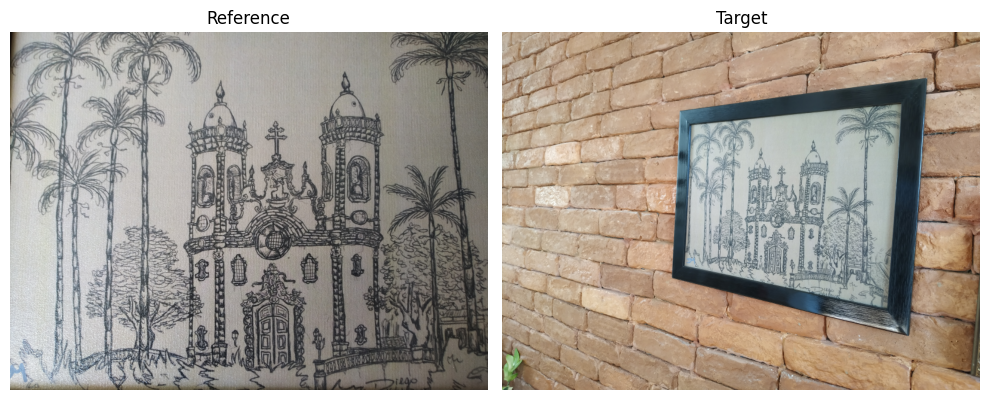

In [3]:
# ── Load images ──
ref_path = os.path.join(_PROJECT_ROOT, "accelerated_features", "assets", "ref.png")
tgt_path = os.path.join(_PROJECT_ROOT, "accelerated_features", "assets", "tgt.png")

if not os.path.exists(ref_path):
    print("Sample images not found — generating synthetic pair.")
    img0 = np.random.randint(0, 256, (400, 600, 3), dtype=np.uint8)
    img1 = np.random.randint(0, 256, (400, 600, 3), dtype=np.uint8)
else:
    img0 = cv2.cvtColor(cv2.imread(ref_path), cv2.COLOR_BGR2RGB)
    img1 = cv2.cvtColor(cv2.imread(tgt_path), cv2.COLOR_BGR2RGB)

print(f"Image 0: {img0.shape}")
print(f"Image 1: {img1.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img0); axes[0].set_title("Reference"); axes[0].axis('off')
axes[1].imshow(img1); axes[1].set_title("Target"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [5]:
# ── Load XFeat model ──
xfeat = XFeat()
xfeat_net = xfeat.net
TOP_K = 512
CG_H, CG_W = 704, 640
MIN_CONF = 0.1

print(f"XFeat model loaded.  detection_threshold={xfeat.detection_threshold}")

loading weights from: c:\UnimelbResearch\xfeat_cuda_graph\accelerated_features\modules/../weights/xfeat.pt
XFeat model loaded.  detection_threshold=0.05


In [6]:
# ── Eager pipeline (baseline) ──
with torch.inference_mode():
    t0 = time.perf_counter()
    
    # 1. XFeat extraction (eager)
    x_t0 = torch.from_numpy(img0).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    x_t1 = torch.from_numpy(img1).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    d0 = xfeat.detectAndCompute(x_t0, top_k=TOP_K)[0]
    d1 = xfeat.detectAndCompute(x_t1, top_k=TOP_K)[0]
    
    # 2. LightGlue matching (eager)
    d0['image_size'] = (img0.shape[1], img0.shape[0])
    d1['image_size'] = (img1.shape[1], img1.shape[0])
    pts0_e, pts1_e, idxs_e = xfeat.match_lighterglue(d0, d1, min_conf=MIN_CONF)
    
    torch.cuda.synchronize()
    eager_total = (time.perf_counter() - t0) * 1000.0

print(f"Eager pipeline: {eager_total:.2f}ms")
print(f"  XFeat: {len(d0['keypoints'])} + {len(d1['keypoints'])} keypoints")
print(f"  LG:    {len(pts0_e)} matches")

Loaded LightGlue model
Eager pipeline: 669.24ms
  XFeat: 512 + 512 keypoints
  LG:    73 matches


In [7]:
# ── Build and capture CUDA Graphs ──
patch_kornia_capture_safe()

# --- XFeat CG ---
cg_net = CGXFeatNet(xfeat_net, H=CG_H, W=CG_W).to(device).eval()
xcg = capture_cg_xfeat(cg_net, H=CG_H, W=CG_W)
print(f"XFeat CG ready @ {CG_H}x{CG_W}")

# --- LightGlue CG ---
lg_model = CGLightGlue().to(device).eval()
lg_model.net.conf.filter_threshold = MIN_CONF
lg_cg = capture_cg_lightglue(lg_model, B=1, M=TOP_K, N=TOP_K)
print(f"LightGlue CG ready M=N={TOP_K}")

XFeat CG ready @ 704x640
Loaded LightGlue model
LightGlue CG ready M=N=512


In [8]:
# ── CUDA Graph pipeline ──
with torch.inference_mode():
    t0 = time.perf_counter()
    
    # 1. XFeat CG extraction
    kpts0, desc0, scores0 = xfeat_cg_extract(
        xcg, img0, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )
    kpts1, desc1, scores1 = xfeat_cg_extract(
        xcg, img1, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )
    
    # 2. LightGlue CG matching
    bufs = lg_cg["bufs"]
    M, N = TOP_K, TOP_K
    n0 = min(len(kpts0), M)
    n1 = min(len(kpts1), N)
    
    bufs["kpts0"].zero_(); bufs["desc0"].zero_(); bufs["mask0"].zero_()
    bufs["kpts1"].zero_(); bufs["desc1"].zero_(); bufs["mask1"].zero_()
    bufs["kpts0"][0, :n0] = kpts0[:n0]
    bufs["desc0"][0, :n0] = desc0[:n0]
    bufs["kpts1"][0, :n1] = kpts1[:n1]
    bufs["desc1"][0, :n1] = desc1[:n1]
    bufs["mask0"][0, :n0, 0] = True
    bufs["mask1"][0, :n1, 0] = True
    bufs["size0"][0] = torch.tensor([img0.shape[1], img0.shape[0]],
                                       device=device, dtype=torch.long)
    bufs["size1"][0] = torch.tensor([img1.shape[1], img1.shape[0]],
                                       device=device, dtype=torch.long)
    
    lg_cg["graph"].replay()
    m0 = lg_cg["outs"][0][0].cpu().numpy()
    m1 = lg_cg["outs"][1][0].cpu().numpy()
    ms0 = lg_cg["outs"][2][0].cpu().numpy()
    
    gi = np.where(m0 >= 0)[0]
    pts0_cg = kpts0[:n0][gi].cpu().numpy()
    pts1_cg = kpts1[:n1][m0[gi].astype(int)].cpu().numpy()
    
    torch.cuda.synchronize()
    cg_total = (time.perf_counter() - t0) * 1000.0

print(f"CUDA Graph pipeline: {cg_total:.2f}ms")
print(f"  XFeat: {len(kpts0)} + {len(kpts1)} keypoints")
print(f"  LG:    {len(pts0_cg)} matches")

CUDA Graph pipeline: 28.92ms
  XFeat: 512 + 512 keypoints
  LG:    71 matches


In [9]:
# ── Comparison ──
print(f"\n{'=' * 50}")
print(f"End-to-End Pipeline Comparison")
print(f"{'=' * 50}")
print(f"{'':>25} {'Eager':>10} {'CUDA Graph':>12} {'Speedup':>8}")
print(f"{chr(45) * 55}")
print(f"{'Total time (ms)':>25} {eager_total:>8.2f}  {cg_total:>8.2f}  "
      f"{eager_total / cg_total:>6.2f}x")
print(f"{'Matches':>25} {len(pts0_e):>10}  {len(pts0_cg):>10}")

# Compare match consistency
n_common = min(len(pts0_e), len(pts0_cg))
if n_common > 0:
    pos_diff = np.abs(pts0_e[:n_common] - pts0_cg[:n_common]).max()
    print(f"\nMax position difference (first {n_common} matches): {pos_diff:.4f} px")
    if pos_diff < 1.0:
        print("✓ Matches are consistent between eager and CG pipelines")
    else:
        print("⚠  Large differences — check threshold / detection parameters")


End-to-End Pipeline Comparison
                               Eager   CUDA Graph  Speedup
-------------------------------------------------------
          Total time (ms)   669.24     28.92   23.14x
                  Matches         73          71

Max position difference (first 71 matches): 634.0000 px
⚠  Large differences — check threshold / detection parameters


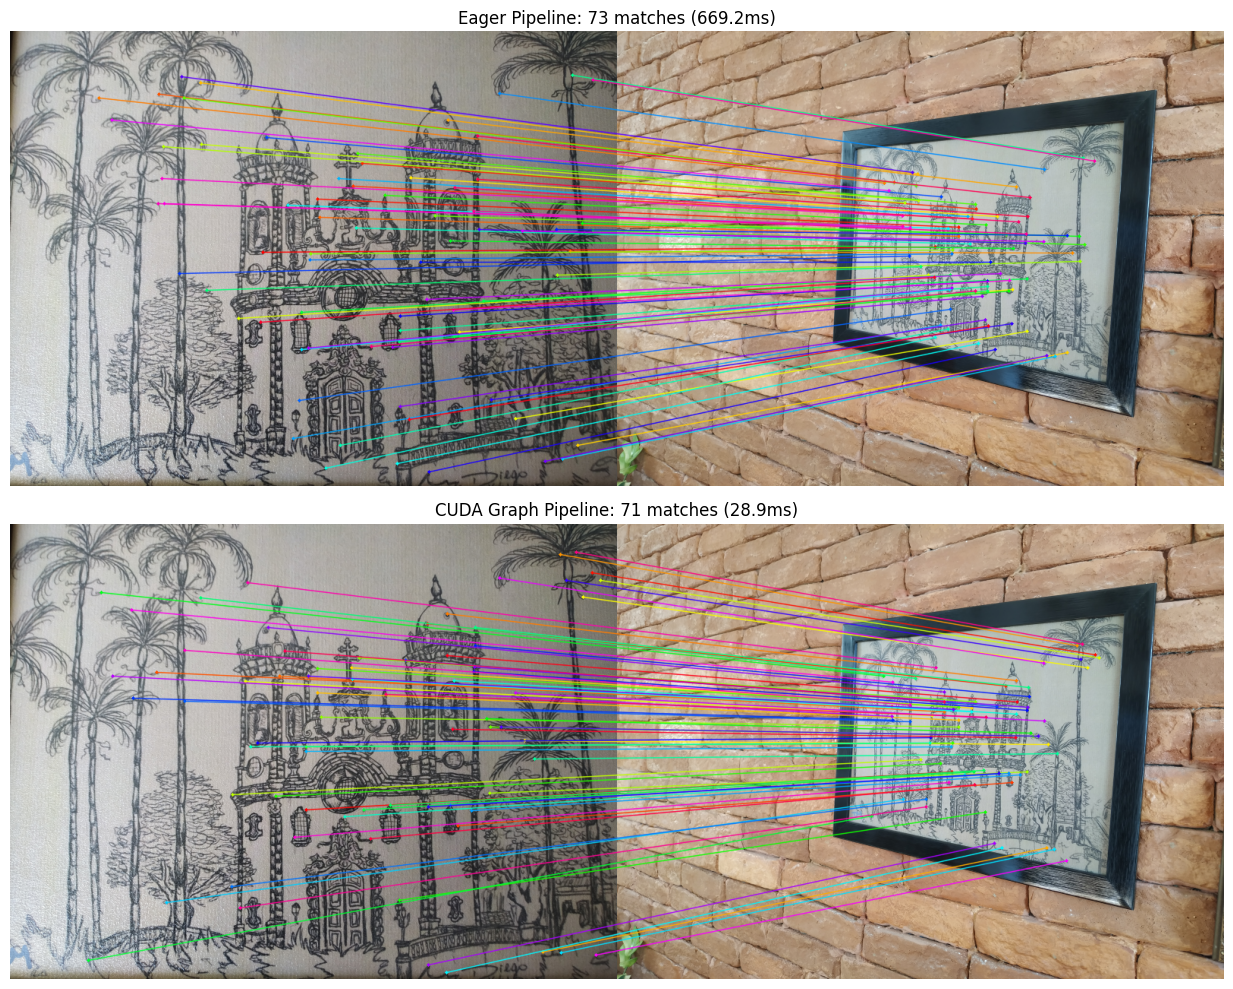

In [10]:
# ── Visualise matches ──
def draw_matches(img0, img1, pts0, pts1, max_draw=100, title=""):
    """Draw match lines between two images."""
    h0, w0 = img0.shape[:2]
    h1, w1 = img1.shape[:2]
    canvas = np.zeros((max(h0, h1), w0 + w1, 3), dtype=np.uint8)
    canvas[:h0, :w0] = img0
    canvas[:h1, w0:w0+w1] = img1
    
    n = min(len(pts0), max_draw)
    colors = plt.cm.hsv(np.linspace(0, 1, n))[:, :3] * 255
    for i in range(n):
        pt0 = (int(pts0[i, 0]), int(pts0[i, 1]))
        pt1 = (int(pts1[i, 0] + w0), int(pts1[i, 1]))
        cv2.circle(canvas, pt0, 2, colors[i].tolist(), -1)
        cv2.circle(canvas, pt1, 2, colors[i].tolist(), -1)
        cv2.line(canvas, pt0, pt1, colors[i].tolist(), 1, cv2.LINE_AA)
    return canvas


fig, axes = plt.subplots(2, 1, figsize=(14, 10))

canvas_e = draw_matches(img0, img1, pts0_e, pts1_e, max_draw=80,
                        title="Eager Pipeline")
axes[0].imshow(canvas_e)
axes[0].set_title(f"Eager Pipeline: {len(pts0_e)} matches ({eager_total:.1f}ms)")
axes[0].axis('off')

canvas_cg = draw_matches(img0, img1, pts0_cg, pts1_cg, max_draw=80,
                         title="CUDA Graph Pipeline")
axes[1].imshow(canvas_cg)
axes[1].set_title(f"CUDA Graph Pipeline: {len(pts0_cg)} matches ({cg_total:.1f}ms)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# ── Repeated timing (robust measurement) ──
WARM, REP = 10, 30

def run_eager_pipeline():
    d0 = xfeat.detectAndCompute(x_t0, top_k=TOP_K)[0]
    d1 = xfeat.detectAndCompute(x_t1, top_k=TOP_K)[0]
    d0['image_size'] = (img0.shape[1], img0.shape[0])
    d1['image_size'] = (img1.shape[1], img1.shape[0])
    xfeat.match_lighterglue(d0, d1, min_conf=MIN_CONF)

def run_cg_pipeline():
    kpts0, desc0, _ = xfeat_cg_extract(
        xcg, img0, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )
    kpts1, desc1, _ = xfeat_cg_extract(
        xcg, img1, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )
    n0 = min(len(kpts0), TOP_K); n1 = min(len(kpts1), TOP_K)
    bufs["kpts0"].zero_(); bufs["desc0"].zero_(); bufs["mask0"].zero_()
    bufs["kpts1"].zero_(); bufs["desc1"].zero_(); bufs["mask1"].zero_()
    bufs["kpts0"][0, :n0] = kpts0[:n0]
    bufs["desc0"][0, :n0] = desc0[:n0]
    bufs["kpts1"][0, :n1] = kpts1[:n1]
    bufs["desc1"][0, :n1] = desc1[:n1]
    bufs["mask0"][0, :n0, 0] = True
    bufs["mask1"][0, :n1, 0] = True
    lg_cg["graph"].replay()

# Warmup
for _ in range(WARM):
    run_eager_pipeline(); torch.cuda.synchronize()
    run_cg_pipeline(); torch.cuda.synchronize()

# Measure
eager_times = []
for _ in range(REP):
    t0 = time.perf_counter(); run_eager_pipeline(); torch.cuda.synchronize()
    eager_times.append((time.perf_counter() - t0) * 1000.0)

cg_times = []
for _ in range(REP):
    t0 = time.perf_counter(); run_cg_pipeline(); torch.cuda.synchronize()
    cg_times.append((time.perf_counter() - t0) * 1000.0)

eager_times = np.array(eager_times)
cg_times = np.array(cg_times)

print(f"\nRepeated timing (n={REP}):")
print(f"{'':>20} {'Eager':>10} {'CUDA Graph':>12} {'Speedup':>8}")
print(f"-" * 52)
print(f"{'p50 (ms)':>20} {np.percentile(eager_times, 50):>8.2f}  "
      f"{np.percentile(cg_times, 50):>8.2f}  "
      f"{np.percentile(eager_times, 50) / np.percentile(cg_times, 50):>6.2f}x")
print(f"{'mean (ms)':>20} {eager_times.mean():>8.2f}  "
      f"{cg_times.mean():>8.2f}  "
      f"{eager_times.mean() / cg_times.mean():>6.2f}x")
print(f"{'std (ms)':>20} {eager_times.std():>8.2f}  {cg_times.std():>8.2f}")


Repeated timing (n=30):
                          Eager   CUDA Graph  Speedup
----------------------------------------------------
            p50 (ms)    36.20     13.50    2.68x
           mean (ms)    38.00     13.27    2.86x
            std (ms)     5.31      1.23
